# Coarse Hand Labeling Tool - Reference Spectra Selection

This notebook provides an interactive tool for selecting bright and shadow regions from HSI images to extract reference spectra.

**Workflow:**
1. Load dataset from `pivot_table.csv`
2. Check `ref_spectra.csv` for previously labeled IDs
3. Start from the last labeled ID (or beginning if none exist)
4. For each sample:
   - Display RGB image
   - Select two circular regions (bright and shadow)
   - Extract average HSI spectra from both regions
   - Save to `ref_spectra.csv`


In [2]:
import cv2
import numpy as np
import pandas as pd
import os
from pathlib import Path
from typing import List, Optional, Tuple, Dict
import torch

# Import UniversalDataset
import sys
sys.path.append('..')
from utils.dataset import UniversalDataset

print("Imports loaded!")


Imports loaded!


## Configuration


In [3]:
# ========== CONFIGURATION ==========

# Path to pivot table CSV
PIVOT_TABLE_PATH = "../pivot_table.csv"

# Path to reference spectra CSV (will be created if doesn't exist)
REF_SPECTRA_PATH = "ref_spectra.csv"

# Root directory for images (for UniversalDataset)
ROOT_IMAGE_DIR = "D:/oil/"

# Wavelengths list (204 values) - MANUALLY SET THIS
# Example: waves = [400, 401, 402, ...]  # 204 values total
# You need to provide the actual wavelength values here
waves = [397.32,
400.20,
403.09,
405.97,
408.85,
411.74,
414.63,
417.52,
420.40,
423.29,
426.19,
429.08,
431.97,
434.87,
437.76,
440.66,
443.56,
446.45,
449.35,
452.25,
455.16,
458.06,
460.96,
463.87,
466.77,
469.68,
472.59,
475.50,
478.41,
481.32,
484.23,
487.14,
490.06,
492.97,
495.89,
498.80,
501.72,
504.64,
507.56,
510.48,
513.40,
516.33,
519.25,
522.18,
525.10,
528.03,
530.96,
533.89,
536.82,
539.75,
542.68,
545.62,
548.55,
551.49,
554.43,
557.36,
560.30,
563.24,
566.18,
569.12,
572.07,
575.01,
577.96,
580.90,
583.85,
586.80,
589.75,
592.70,
595.65,
598.60,
601.55,
604.51,
607.46,
610.42,
613.38,
616.34,
619.30,
622.26,
625.22,
628.18,
631.15,
634.11,
637.08,
640.04,
643.01,
645.98,
648.95,
651.92,
654.89,
657.87,
660.84,
663.81,
666.79,
669.77,
672.75,
675.73,
678.71,
681.69,
684.67,
687.65,
690.64,
693.62,
696.61,
699.60,
702.58,
705.57,
708.57,
711.56,
714.55,
717.54,
720.54,
723.53,
726.53,
729.53,
732.53,
735.53,
738.53,
741.53,
744.53,
747.54,
750.54,
753.55,
756.56,
759.56,
762.57,
765.58,
768.60,
771.61,
774.62,
777.64,
780.65,
783.67,
786.68,
789.70,
792.72,
795.74,
798.77,
801.79,
804.81,
807.84,
810.86,
813.89,
816.92,
819.95,
822.98,
826.01,
829.04,
832.07,
835.11,
838.14,
841.18,
844.22,
847.25,
850.29,
853.33,
856.37,
859.42,
862.46,
865.50,
868.55,
871.60,
874.64,
877.69,
880.74,
883.79,
886.84,
889.90,
892.95,
896.01,
899.06,
902.12,
905.18,
908.24,
911.30,
914.36,
917.42,
920.48,
923.55,
926.61,
929.68,
932.74,
935.81,
938.88,
941.95,
945.02,
948.10,
951.17,
954.24,
957.32,
960.40,
963.47,
966.55,
969.63,
972.71,
975.79,
978.88,
981.96,
985.05,
988.13,
991.22,
994.31,
997.40,
1000.49,
1003.58]

# Example (replace with your actual wavelengths):
# waves = list(range(400, 604))  # This is just an example - use your actual wavelengths

print("Configuration loaded!")
print(f"Waves list: {'Set' if waves is not None else 'NOT SET - Please configure!'}")


Configuration loaded!
Waves list: Set


## Load and Prepare Dataset


In [4]:
def load_or_create_ref_spectra(csv_path: str) -> pd.DataFrame:
    """Load existing ref_spectra.csv or create empty one."""
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        print(f"Loaded existing ref_spectra.csv with {len(df)} entries")
        return df
    else:
        # Create empty dataframe with id and 204 wave columns
        columns = ['id'] + [f'wave_{i}' for i in range(204)]
        df = pd.DataFrame(columns=columns)
        print(f"Created new ref_spectra.csv")
        return df

def get_last_labeled_id(ref_df: pd.DataFrame) -> Optional[int]:
    """Get the last (maximum) ID from ref_spectra.csv."""
    if len(ref_df) == 0:
        return None
    return int(ref_df['id'].max())

def get_start_index(pivot_df: pd.DataFrame, last_id: Optional[int]) -> int:
    """Get the starting index in the dataset based on last_id."""
    if last_id is None:
        print("No previous labels found - starting from beginning")
        return 0
    else:
        # Find the position of the first ID greater than last_id
        greater_mask = pivot_df['id'] > last_id
        greater_indices = np.where(greater_mask)[0]
        if len(greater_indices) > 0:
            start_idx = int(greater_indices[0])
            start_id = pivot_df.iloc[start_idx]['id']
            print(f"Starting from ID {start_id} (position {start_idx})")
            return start_idx
        else:
            print("All samples already labeled - starting from beginning")
            return 0

# Load pivot table
print("=" * 50)
print("Step 1: Loading pivot table...")
print("=" * 50)
pivot_df = pd.read_csv(PIVOT_TABLE_PATH)
pivot_df = pivot_df[~pivot_df['id'].isna()]
pivot_df['id'] = pivot_df['id'].astype(int)
print(f"Loaded pivot table with {len(pivot_df)} rows")

# Load or create ref_spectra
print("\n" + "=" * 50)
print("Step 2: Loading/creating ref_spectra.csv...")
print("=" * 50)
ref_df = load_or_create_ref_spectra(REF_SPECTRA_PATH)

# Get last labeled ID
last_id = get_last_labeled_id(ref_df)
if last_id is not None:
    print(f"Last labeled ID: {last_id}")
else:
    print("No previous labels found")

# Get starting index (but keep full dataset for re-labeling)
print("\n" + "=" * 50)
print("Step 3: Preparing dataset...")
print("=" * 50)
start_idx = get_start_index(pivot_df, last_id)

print(f"Dataset ready: {len(pivot_df)} total samples")
print(f"Starting from index: {start_idx}")


Step 1: Loading pivot table...
Loaded pivot table with 620 rows

Step 2: Loading/creating ref_spectra.csv...
Loaded existing ref_spectra.csv with 257 entries
Last labeled ID: 2881

Step 3: Preparing dataset...
Starting from ID 2882 (position 257)
Dataset ready: 620 total samples
Starting from index: 257


## Create UniversalDataset


In [5]:
sample_id = 2599
pivot_df[pivot_df['id'] == sample_id]

,id,angle,container,volume,oil,date
0,2599,90.0,petri,50 ml,sunflower,17_Dec_25


In [6]:
# Create UniversalDataset with full dataframe (allows re-labeling)
# Note: load_mask=False since we don't need masks for this tool
if len(pivot_df) > 0:
    ds = UniversalDataset(
        root_dir=ROOT_IMAGE_DIR,
        meta=pivot_df,
        load_hsi=True,
        load_mask=False,  # Don't load masks for coarse labeling
        mask_dir = 'nonepath',
        render_rgb=True,
        crop_size=None  # Use full image size
    )
    print(f"Dataset created with {len(ds)} samples")
    print(f"Sample IDs: {[ds[i]['id'] for i in range(min(5, len(ds)))]}...")
    print(f"Will start from index {start_idx}")
else:
    ds = None
    start_idx = 0
    print("No dataset created - no samples to label")


Dataset created with 620 samples
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Sample IDs: [2599, 2600, 2601, 2602, 2603]...
Will start from index 257


## Interactive Labeling Tool Class


In [7]:
class CoarseLabelingTool:
    """
    Interactive tool for selecting bright and shadow regions to extract reference spectra.
    
    Controls:
    - Mouse wheel: Adjust circle radius (only for first selection)
    - Left click: Select bright region
    - Right click: Select shadow region
    - 's': Save spectral signature to CSV and switch to next sample
    - 'n': Switch to next sample (does not save)
    - 'r': Reset current selections
    - Arrow Left/Right: Navigate between samples
    - 'q' or ESC: Quit and close window
    """
    
    def __init__(self, dataset, ref_df: pd.DataFrame, ref_path: str, waves: List[float]):
        self.dataset = dataset
        self.ref_df = ref_df
        self.ref_path = ref_path
        self.waves = waves
        
        if len(waves) != 204:
            raise ValueError(f"Waves list must have 204 values, got {len(waves)}")
        
        self.current_idx = 0  # Will be set to start_idx
        self.radius = 20  # Initial circle radius
        self.bright_center = None  # (x, y) for bright region
        self.shadow_center = None  # (x, y) for shadow region
        self.mouse_x = -1
        self.mouse_y = -1
        self.selection_mode = 'bright'  # 'bright' or 'shadow'
        
        # Load current sample
        self.load_current_sample()
    
    def load_current_sample(self):
        """Load the current sample from dataset."""
        if self.current_idx >= len(self.dataset):
            print("All samples processed!")
            return False
        
        sample = self.dataset[self.current_idx]
        self.current_id = sample['id']
        self.current_rgb = sample['rgb']  # (3, H, W) tensor
        self.current_hsi = sample['hsi']  # (Bands, H, W) tensor
        
        # Convert RGB to numpy for display (H, W, 3) uint8
        rgb_np = self.current_rgb.permute(1, 2, 0).numpy()
        rgb_np = (rgb_np * 255).astype(np.uint8)
        rgb_np = cv2.cvtColor(rgb_np, cv2.COLOR_RGB2BGR)  # OpenCV uses BGR
        self.display_image = rgb_np.copy()
        
        # Reset selections for new sample
        self.bright_center = None
        self.shadow_center = None
        self.selection_mode = 'bright'
        
        # Reset mouse position
        self.mouse_x = -1
        self.mouse_y = -1
        
        print(f"\nImage {self.current_idx + 1}/{len(self.dataset)}")
        print(f"Sample ID: {self.current_id}")
        print(f"RGB shape: {self.current_rgb.shape}")
        print(f"HSI shape: {self.current_hsi.shape}")
        
        self.update_display()
        return True
    
    def update_display(self):
        """Update display with current selections and preview circle."""
        display = self.display_image.copy()
        
        # Draw bright region if selected
        if self.bright_center is not None:
            cv2.circle(display, self.bright_center, self.radius, (0, 255, 0), 2)  # Green
            cv2.putText(display, "BRIGHT", 
                       (self.bright_center[0] - 30, self.bright_center[1] - self.radius - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
        
        # Draw shadow region if selected
        if self.shadow_center is not None:
            cv2.circle(display, self.shadow_center, self.radius, (255, 0, 0), 2)  # Blue
            cv2.putText(display, "SHADOW",
                       (self.shadow_center[0] - 30, self.shadow_center[1] - self.radius - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
        
        # Draw preview circle following mouse (transparent red)
        if self.mouse_x >= 0 and self.mouse_y >= 0:
            h, w = display.shape[:2]
            if 0 <= self.mouse_x < w and 0 <= self.mouse_y < h:
                # Create overlay for transparent circle
                overlay = display.copy()
                cv2.circle(overlay, (self.mouse_x, self.mouse_y), self.radius, (0, 0, 255), -1)
                cv2.addWeighted(overlay, 0.3, display, 0.7, 0, display)
                # Draw edge
                cv2.circle(display, (self.mouse_x, self.mouse_y), self.radius, (0, 0, 255), 2)
        
        # Add status text
        status_text = f"Mode: {self.selection_mode.upper()} | Radius: {self.radius} | Wheel: Adjust"
        cv2.putText(display, status_text, (10, display.shape[0] - 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        cv2.putText(display, status_text, (10, display.shape[0] - 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 1)
        
        # Add instructions
        instructions = [
            f"Sample ID: {self.current_id} | [{self.current_idx + 1}/{len(self.dataset)}]",
            "Left Click: Bright | Right Click: Shadow | 's': Save | 'n': Next | 'r': Reset | 'q': Quit"
        ]
        for i, text in enumerate(instructions):
            cv2.putText(display, text, (10, display.shape[0] - 30 + i * 20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 3)
            cv2.putText(display, text, (10, display.shape[0] - 30 + i * 20),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
        
        self.display_image_updated = display
    
    def mouse_callback(self, event, x, y, flags, param):
        """Handle mouse events."""
        self.mouse_x = x
        self.mouse_y = y
        
        if event == cv2.EVENT_LBUTTONDOWN:
            if self.selection_mode == 'bright':
                # Select bright region
                self.bright_center = (x, y)
                self.selection_mode = 'shadow'  # Next selection will be shadow
                self.update_display()
            elif self.selection_mode == 'shadow':
                self.shadow_center = (x, y)
                self.selection_mode = 'bright'  # Next selection will be bright
                self.update_display()            
        elif event == cv2.EVENT_MOUSEWHEEL:
            # Adjust radius (only for first selection)
            if self.bright_center is None:
                delta = flags
                if delta > 0:  # Scroll up
                    self.radius = min(100, self.radius + 2)
                elif delta < 0:  # Scroll down
                    self.radius = max(5, self.radius - 2)
                self.update_display()
    
    def extract_spectra(self) -> Optional[np.ndarray]:
        """Extract average spectra from selected regions. Returns (204,) array."""
        if self.bright_center is None or self.shadow_center is None:
            return None
        
        # Get HSI as numpy (Bands, H, W)
        hsi_np = self.current_hsi.numpy()
        h, w = hsi_np.shape[1], hsi_np.shape[2]
        
        # Create masks for both circles
        y_coords, x_coords = np.ogrid[:h, :w]
        
        # Bright region mask
        bright_dist = np.sqrt((x_coords - self.bright_center[0])**2 + 
                             (y_coords - self.bright_center[1])**2)
        bright_mask = bright_dist <= self.radius
        
        # Shadow region mask
        shadow_dist = np.sqrt((x_coords - self.shadow_center[0])**2 + 
                              (y_coords - self.shadow_center[1])**2)
        shadow_mask = shadow_dist <= self.radius
        
        # Combine masks
        combined_mask = bright_mask | shadow_mask
        
        # Extract spectra from both regions and average
        # hsi_np shape: (Bands, H, W)
        # Use advanced indexing to extract pixels where mask is True
        y_indices, x_indices = np.where(combined_mask)
        # hsi_np[:, y_indices, x_indices] gives (Bands, num_pixels)
        # Mean across pixels (axis=1) gives (Bands,)
        if len(y_indices) > 0:
            spectra = hsi_np[:, y_indices, x_indices].mean(axis=1)  # (Bands,)
        else:
            print("Warning: No pixels selected in mask!")
            return None
        
        return spectra
    
    def save_current(self):
        """Save current selections to ref_spectra.csv."""
        if self.bright_center is None or self.shadow_center is None:
            print("Error: Both bright and shadow regions must be selected!")
            return False
        
        # Extract spectra
        spectra = self.extract_spectra()
        if spectra is None:
            print("Error: Could not extract spectra!")
            return False
        
        # Create new row
        new_row = {'id': self.current_id}
        for i, wave_val in enumerate(self.waves):
            new_row[f'wave_{i}'] = spectra[i]
        
        # Check if this ID already exists (for re-labeling)
        existing_idx = self.ref_df.index[self.ref_df['id'] == self.current_id].tolist()
        if existing_idx:
            # Update existing entry
            for idx in existing_idx:
                for key, value in new_row.items():
                    self.ref_df.at[idx, key] = value
            print(f"Updated spectra for ID {self.current_id}")
        else:
            # Add new entry
            new_df = pd.DataFrame([new_row])
            self.ref_df = pd.concat([self.ref_df, new_df], ignore_index=True)
            print(f"Saved spectra for ID {self.current_id}")
        
        # Save to CSV
        self.ref_df.to_csv(self.ref_path, index=False)
        
        return True
    
    def reset_selections(self):
        """Reset current selections."""
        self.bright_center = None
        self.shadow_center = None
        self.selection_mode = 'bright'
        self.update_display()
        print("Selections reset")
    
    def next_sample(self, save_current: bool = False):
        """Move to next sample."""
        if save_current:
            self.save_current()
        
        self.current_idx += 1
        if self.current_idx < len(self.dataset):
            return self.load_current_sample()
        else:
            print("\nAll samples processed!")
            return False
    
    def previous_sample(self):
        """Move to previous sample."""
        if self.current_idx > 0:
            self.current_idx -= 1
            return self.load_current_sample()
        return False
    
    def run(self):
        """Run the interactive labeling session."""
        window_name = "Coarse Labeling Tool - Press 'q' to quit"
        cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
        
        def mouse_wrapper(event, x, y, flags, param):
            self.mouse_callback(event, x, y, flags, param)
        
        cv2.setMouseCallback(window_name, mouse_wrapper)
        
        print("\n=== Coarse Labeling Tool Started ===")
        print("Controls:")
        print("  Mouse Wheel: Adjust circle radius (before first selection)")
        print("  Left Click: Select bright region")
        print("  Right Click: Select shadow region")
        print("  's': Save spectral signature to CSV and switch to next sample")
        print("  'n': Switch to next sample (don't save)")
        print("  'r': Reset current selections")
        print("  Arrow Left/Right: Navigate samples")
        print("  'q' or ESC: Quit")
        print("=" * 40)
        
        while True:
            self.update_display()
            cv2.imshow(window_name, self.display_image_updated)
            
            # Use waitKey with longer delay to ensure keys are captured
            # On Windows, we need to check for -1 (no key pressed)
            key_code = cv2.waitKey(30)  # 30ms delay for better key capture
            
            if key_code == -1:
                continue  # No key pressed, continue loop
            
            key = key_code & 0xFF
            
            # Debug: uncomment to see what keys are being pressed
            # if key != 255:  # 255 is often returned when no key is pressed
            #     print(f"Key pressed: {key} (char: {chr(key) if 32 <= key <= 126 else 'N/A'})")
            
            if key == ord('q') or key == 27:  # 'q' or ESC
                print("\nQuitting labeling session...")
                break
            elif key == ord('s'):  # Save spectral signature to CSV and move to next
                if self.save_current():
                    if not self.next_sample(save_current=False):
                        break
            elif key == ord('n'):  # Next without saving
                if not self.next_sample(save_current=False):
                    break
            elif key == ord('r'):  # Reset
                self.reset_selections()
            elif key == ord('+') or key == ord('='):  # Increase radius
                if self.bright_center is None:
                    self.radius = min(100, self.radius + 2)
                    self.update_display()
            elif key == ord('-') or key == ord('_'):  # Decrease radius
                if self.bright_center is None:
                    self.radius = max(5, self.radius - 2)
                    self.update_display()
            elif key == 81 or key == 2:  # Left arrow
                self.previous_sample()
            elif key == 83 or key == 3:  # Right arrow
                if not self.next_sample(save_current=False):
                    break
        
        cv2.destroyAllWindows()
        return self.ref_df

print("CoarseLabelingTool class defined!")


CoarseLabelingTool class defined!


## Run Labeling Tool

**IMPORTANT:** Make sure you have set the `waves` list in the configuration cell above (204 wavelength values)!


In [8]:
# Check if waves are configured
if waves is None:
    print("ERROR: Please configure the 'waves' list in the configuration cell!")
    print("The waves list should contain 204 wavelength values.")
else:
    if len(waves) != 204:
        print(f"ERROR: Waves list must have 204 values, got {len(waves)}")
    elif ds is not None and len(ds) > 0:
        # Create and run tool
        tool = CoarseLabelingTool(
            dataset=ds,
            ref_df=ref_df,
            ref_path=REF_SPECTRA_PATH,
            waves=waves
        )
        
        # Set starting index
        tool.current_idx = start_idx
        if start_idx < len(ds):
            tool.load_current_sample()
        
        # Run labeling session
        final_ref_df = tool.run()
        
        print(f"\n=== Session Complete ===")
        print(f"Total labeled: {len(final_ref_df)}")
        print(f"Reference spectra saved to: {REF_SPECTRA_PATH}")
    else:
        print("No samples to label!")


Error loading mask: 'NoneType' object has no attribute 'read'
info: None

Image 1/620
Sample ID: 2599
RGB shape: torch.Size([3, 512, 512])
HSI shape: torch.Size([204, 512, 512])
Error loading mask: 'NoneType' object has no attribute 'read'
info: None

Image 258/620
Sample ID: 2882
RGB shape: torch.Size([3, 512, 512])
HSI shape: torch.Size([204, 512, 512])

=== Coarse Labeling Tool Started ===
Controls:
  Mouse Wheel: Adjust circle radius (before first selection)
  Left Click: Select bright region
  Right Click: Select shadow region
  's': Save spectral signature to CSV and switch to next sample
  'n': Switch to next sample (don't save)
  'r': Reset current selections
  Arrow Left/Right: Navigate samples
  'q' or ESC: Quit
Saved spectra for ID 2882
Error loading mask: 'NoneType' object has no attribute 'read'
info: None

Image 259/620
Sample ID: 2883
RGB shape: torch.Size([3, 512, 512])
HSI shape: torch.Size([204, 512, 512])
Saved spectra for ID 2883
Error loading mask: 'NoneType' objec

In [9]:
rsdf = pd.read_csv('ref_spectra.csv')

Error loading mask: 'NoneType' object has no attribute 'read'
info: None
Error loading mask: 'NoneType' object has no attribute 'read'
info: None
(262144,)


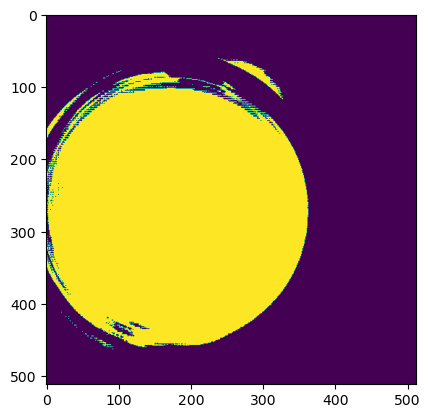

In [10]:
import matplotlib.pyplot as plt
def bulk_cos_sim(image, reference_spectrum, threshold=0.999):
    bands, h, w = image.shape
    flat_image = image.permute(1, 2, 0).reshape(-1, bands)
    cos_sims = np.dot(flat_image, reference_spectrum.transpose(1, 0)).squeeze(1) / (np.linalg.norm(flat_image, axis=1) * np.linalg.norm(reference_spectrum))
    print(cos_sims.shape)
    return (cos_sims.reshape(h, w) > threshold).astype(np.uint8)
plt.imshow(bulk_cos_sim(ds[0]['hsi'], rsdf[rsdf['id'] == ds[0]['id']][rsdf.columns[1:]].values))